In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier

import joblib
import pickle

# ==========================================
# 1. Set local file path
# ==========================================

# Path to the Downloads folder
base_path = "/Users/li0o0sun/projects/Projectwork2026/data"
file_name = "09_filtered_all_data.pkl"
full_path = os.path.join(base_path, file_name)


def load_local_data(path):
    """
    Load EMG dataset from a local pickle file,
    perform memory optimization, detect bad channels,
    and convert gait phase into circular coordinates.
    """

    # Check whether file exists
    if not os.path.exists(path):
        print(f" File not found: {path}")
        print("Please check the filename or confirm the file is in the Downloads folder.")
        return None

    print(f" Loading data from: {path} ...")

    try:
        # ------------------------------------------
        # Load pickle file into pandas DataFrame
        # ------------------------------------------
        df = pd.read_pickle(path)

        # ------------------------------------------
        # Memory optimization
        # Convert float64 columns to float32
        # (reduces memory usage for large datasets)
        # ------------------------------------------
        float_cols = df.select_dtypes(include=['float64']).columns
        df[float_cols] = df[float_cols].astype('float32')

        print(" Data loaded successfully!")
        print(f" Shape: {df.shape[0]} rows x {df.shape[1]} columns")

        # ------------------------------------------
        # Bad channel detection
        # Method:
        # 1. Compute median power of each EMG channel
        # 2. Calculate Z-score across channels
        # 3. Channels beyond ±3 std are marked as bad
        # ------------------------------------------
        emg_cols = [
            c for c in df.columns
            if 'Ch' in str(c) and '(' in str(c) and 'Ankle' not in str(c)
        ]

        if emg_cols:
            # Median power of each channel
            channel_medians = (df[emg_cols] ** 2).median()

            # Z-score normalization
            z_scores = (
                channel_medians - channel_medians.mean()
            ) / (channel_medians.std() + 1e-6)

            # Detect abnormal channels
            bad_channels = z_scores[abs(z_scores) > 3].index.tolist()

            if bad_channels:
                print(f" Found {len(bad_channels)} bad channels: {bad_channels}")
            else:
                print(" Signal quality looks good. No abnormal channels detected.")

        # ------------------------------------------
        # Convert gait phase (0–100%) into circular coordinates
        # This avoids discontinuity between 0% and 100%
        # ------------------------------------------
        if 'Activity %' in df.columns:
            theta = (df['Activity %'] / 100) * 2 * np.pi

            df['phase_x'] = np.cos(theta)
            df['phase_y'] = np.sin(theta)

            print(" Gait phase converted to circular coordinates (cos, sin).")

        return df

    except Exception as e:
        print(f" Loading failed: {e}")
        return None


# Execute loading
df = load_local_data(full_path)


 Loading data from: /Users/li0o0sun/projects/Projectwork2026/data/09_filtered_all_data.pkl ...
 Data loaded successfully!
 Shape: 1488351 rows x 162 columns


In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


class BiosignalPipeline:
    def __init__(self, window_size=200, overlap=100):
        self.window_size = window_size
        self.overlap = overlap
        self.step_size = window_size - overlap
        
        self.scaler = StandardScaler() # shrinks/stretches data so they all live on the exact same scale
        
        self.lda_model = LinearDiscriminantAnalysis()
        # n_estimators=100 means 100 trees. n_jobs=-1 uses all your CPU cores to train faster.
        self.rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
        self.svm_model = SVC(kernel='rbf')
        
    # ==========================================
    # 1. Feature Definition & Spatial Pooling
    # ==========================================
    def reduce_emg_channels(self, df):
        """
        Reduces 64 TA and 64 GM channels into a smaller set of virtual channels.
        Currently averages every 16 channels into 1 (resulting in 4 TA and 4 GM channels).
        Modify 'group_size' once you know your specific electrode grid layout (e.g. 8x8).
        """
        print(" Reducing EMG dimensionality...")
        ta_cols = [c for c in df.columns if 'EMG_TA' in c]
        gm_cols = [c for c in df.columns if 'EMG_GM' in c]
        
        group_size = 16 
        
        # Pool TA channels
        for i in range(0, 64, group_size):
            cols_to_pool = ta_cols[i:i+group_size]
            df[f'EMG_TA_Pool_{i//group_size}'] = df[cols_to_pool].mean(axis=1)
            
        # Pool GM channels
        for i in range(0, 64, group_size):
            cols_to_pool = gm_cols[i:i+group_size]
            df[f'EMG_GM_Pool_{i//group_size}'] = df[cols_to_pool].mean(axis=1)
            
        # Drop the original 128 channels to save memory
        df.drop(columns=ta_cols + gm_cols, inplace=True)
        return df

    # ==========================================
    # 2. Window Segmentation
    # ==========================================
    def segment_and_extract(self, df):
        """
        Slides a window across the dataframe, extracting features per window.
        """
        print(" Segmenting signals and extracting features... (This may take a minute)")
        
        # Isolate column groups
        emg_cols = [c for c in df.columns if 'EMG_TA_Pool' in c or 'EMG_GM_Pool' in c]
        gonio_cols = [c for c in df.columns if c.startswith('G_')]
        imu_cols = [c for c in df.columns if c.endswith('-f') or c.endswith('-c') or c.endswith('-q') or c.endswith('-h')]
        
        X_features = []
        y_labels = []
        
        # Explicitly cast to float32 so NumPy math functions work perfectly
        emg_data = df[emg_cols].to_numpy(dtype=np.float32)
        gonio_data = df[gonio_cols].to_numpy(dtype=np.float32)
        imu_data = df[imu_cols].to_numpy(dtype=np.float32)
        labels = df['Activity'].values
        
        n_samples = len(df)
        
        for start_idx in range(0, n_samples - self.window_size, self.step_size):
            end_idx = start_idx + self.window_size
            
            # --- Label Voting ---
            # Get the most frequent activity label in this window
            window_labels = labels[start_idx:end_idx]
            unique, counts = np.unique(window_labels, return_counts=True)
            majority_label = unique[np.argmax(counts)]
            
            # Skip window if it contains NaN labels or transitions you want to ignore
            if pd.isna(majority_label):
                continue
                
            y_labels.append(majority_label)
            
            # --- Feature Extraction per Sensor Type ---
            window_features = []
            
            # 1. EMG Features (RMS, Mean Absolute Value, Waveform Length, Zero Crossings)
            w_emg = emg_data[start_idx:end_idx]
            rms = np.sqrt(np.mean(w_emg**2, axis=0))
            mav = np.mean(np.abs(w_emg), axis=0)
            wl = np.sum(np.abs(np.diff(w_emg, axis=0)), axis=0)
            # Zero crossing (boolean casted to int and summed)
            zc = np.sum((w_emg[:-1] * w_emg[1:]) < 0, axis=0)
            
            window_features.extend(rms)
            window_features.extend(mav)
            window_features.extend(wl)
            window_features.extend(zc)
            
            # 2. IMU Features (Mean, Std, RMS, Energy)
            w_imu = imu_data[start_idx:end_idx]
            imu_mean = np.mean(w_imu, axis=0)
            imu_std = np.std(w_imu, axis=0)
            imu_rms = np.sqrt(np.mean(w_imu**2, axis=0))
            imu_energy = np.sum(w_imu**2, axis=0)
            
            window_features.extend(imu_mean)
            window_features.extend(imu_std)
            window_features.extend(imu_rms)
            window_features.extend(imu_energy)
            
            # 3. Goniometer Features (Mean, Std, Range/Peak-to-Peak)
            # w_gonio = gonio_data[start_idx:end_idx]
            # g_mean = np.mean(w_gonio, axis=0)
            # g_std = np.std(w_gonio, axis=0)
            # g_range = np.ptp(w_gonio, axis=0) # Peak-to-peak (max - min)
            
            # window_features.extend(g_mean)
            # window_features.extend(g_std)
            # window_features.extend(g_range)
            
            X_features.append(window_features)
            
        return np.array(X_features), np.array(y_labels)

    # ==========================================
    # 3. Model Training & Evaluation
    # ==========================================
    def run_pipeline(self, df):
        # Step 1: Reduce Channels
        # df_reduced = self.reduce_emg_channels(df.copy())
        
        # Step 2: Segment & Extract
        X, y = self.segment_and_extract(df)
        print(f" Extracted Feature Matrix Shape: {X.shape} (Windows x Features)")
        
        # Step 3: Stratified Chronological Split
        print(" Splitting data chronologically per class...")
        X_train_list, X_test_list, y_train_list, y_test_list = [], [], [], []
        
        # find the unique movement label
        unique_classes = np.unique(y)
        
        for cls in unique_classes:
            # Find the index of all samples in the current category
            cls_indices = np.where(y == cls)[0]
            
            # Calculate the 80% split within the current category in chronological order
            split_point = int(len(cls_indices) * 0.8)
            
            # Get the training and test indices
            train_idx = cls_indices[:split_point]
            test_idx = cls_indices[split_point:]
            
            # Retrieve data based on the index and append it to the list
            X_train_list.extend(X[train_idx])
            y_train_list.extend(y[train_idx])
            
            X_test_list.extend(X[test_idx])
            y_test_list.extend(y[test_idx])
            
        # Convert the list back to a NumPy array
        X_train = np.array(X_train_list)
        X_test = np.array(X_test_list)
        y_train = np.array(y_train_list)
        y_test = np.array(y_test_list)

        # Normalize features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Step 4: Train Classifier
        print(" Training Linear Discriminant Analysis (LDA) model...")
        self.lda_model.fit(X_train_scaled, y_train)
        
        # Step 5: Evaluate
        print(" Evaluating model on test data...")
        y_pred = self.lda_model.predict(X_test_scaled)
        
        print("\n=== Classification Report ===")
        print(classification_report(y_test, y_pred))
        
        return self.lda_model, self.scaler, X_test_scaled, y_test, y_pred


# ==========================================
# Execution Block
# ==========================================
# Assuming 'df' is the dataframe returned by your load_local_data() function

if df is not None:
    # Initialize the pipeline (assuming 1000Hz sampling, 200ms = 200 samples)
    # Adjust window_size and overlap based on your exact sampling frequency!
    pipeline = BiosignalPipeline(window_size=200, overlap=100)
    
    # Run everything
    trained_model, fitted_scaler, X_test, y_test, y_pred = pipeline.run_pipeline(df)

 Segmenting signals and extracting features... (This may take a minute)
 Extracted Feature Matrix Shape: (14882, 96) (Windows x Features)
 Splitting data chronologically per class...
 Training Linear Discriminant Analysis (LDA) model...
 Evaluating model on test data...

=== Classification Report ===
              precision    recall  f1-score   support

         run       1.00      1.00      1.00       733
       squat       0.77      0.56      0.64       227
      squat_       0.78      0.69      0.73       206
        step       0.89      0.85      0.87       280
       step_       0.86      0.89      0.88       274
         sts       0.59      0.77      0.67       270
        sts_       0.70      0.72      0.71       258
        walk       1.00      1.00      1.00       732

    accuracy                           0.87      2980
   macro avg       0.82      0.81      0.81      2980
weighted avg       0.88      0.87      0.87      2980



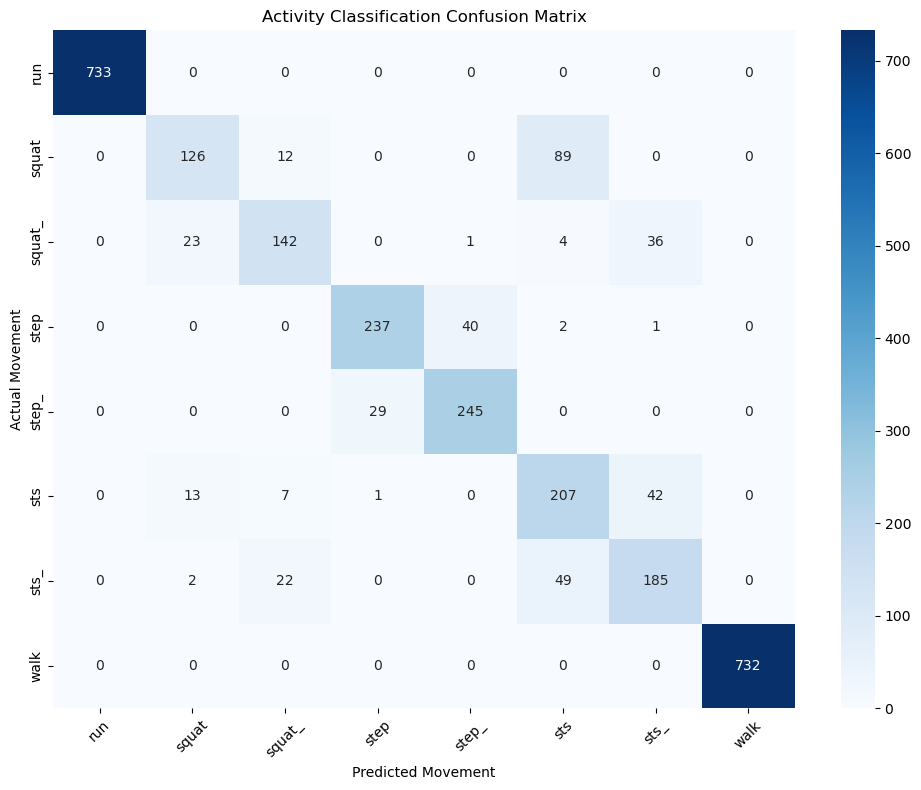

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels):
    """Plots a heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title('Activity Classification Confusion Matrix')
    plt.ylabel('Actual Movement')
    plt.xlabel('Predicted Movement')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Get the unique labels in sorted order to ensure axes match
class_labels = sorted(list(set(y_test)))

# Call the function using the outputs from your pipeline
plot_confusion_matrix(y_test, y_pred, class_labels)

In [4]:
import joblib
import os

# 1. Create a directory for your saved models
save_dir = "/Users/li0o0sun/projects/Projectwork2026/models"
os.makedirs(save_dir, exist_ok=True)

# 2. Save the Scaler and the Model
scaler_path = os.path.join(save_dir, 'biosignal_scaler.pkl')
model_path = os.path.join(save_dir, 'lda_model.pkl')

joblib.dump(fitted_scaler, scaler_path)
joblib.dump(trained_model, model_path)

print(f" Scaler saved to: {scaler_path}")
print(f" Model saved to: {model_path}")

# Note: To load them later in your real-time script, you simply do:
# loaded_scaler = joblib.load(scaler_path)
# loaded_model = joblib.load(model_path)

 Scaler saved to: /Users/li0o0sun/projects/Projectwork2026/models/biosignal_scaler.pkl
 Model saved to: /Users/li0o0sun/projects/Projectwork2026/models/lda_model.pkl


In [7]:
# ==========================================
# 2. Export Functions
# ==========================================
def export_model_to_c(scaler, lda, output_file="model_lda.h"):
    print(f"\n Generating C header for models: {output_file}...")
    try:
        mean = scaler.mean_
        scale = scaler.scale_
        coef = lda.coef_           
        intercept = lda.intercept_ 
        n_classes, n_features = coef.shape

        with open(output_file, 'w') as f:
            f.write("/* Auto-generated LDA Model Parameters */\n")
            f.write("#ifndef MODEL_LDA_H\n#define MODEL_LDA_H\n\n")
            f.write(f"#define NUM_FEATURES {n_features}\n")
            f.write(f"#define NUM_CLASSES {n_classes}\n\n")

            # Scaler
            f.write("const float scaler_mean[NUM_FEATURES] = {\n    " + 
                    ", ".join([f"{x:.6f}f" for x in mean]) + "\n};\n\n")
            f.write("const float scaler_scale[NUM_FEATURES] = {\n    " + 
                    ", ".join([f"{x:.6f}f" for x in scale]) + "\n};\n\n")

            # LDA Intercept
            f.write("const float lda_intercept[NUM_CLASSES] = {\n    " + 
                    ", ".join([f"{x:.6f}f" for x in intercept]) + "\n};\n\n")
            
            # LDA Coefficients
            f.write("const float lda_coef[NUM_CLASSES][NUM_FEATURES] = {\n")
            for i in range(n_classes):
                row_str = ", ".join([f"{x:.6f}f" for x in coef[i]])
                f.write(f"    {{{row_str}}}")
                if i < n_classes - 1: f.write(",\n")
                else: f.write("\n")
            f.write("};\n\n")

            # Classes (Just write 0 to 7 to match our encoded labels)
            f.write("const int lda_classes[NUM_CLASSES] = {" + 
                    ", ".join([str(i) for i in range(n_classes)]) + "};\n\n")
            f.write("#endif // MODEL_LDA_H\n")
            
        print(f"✅ Successfully generated {output_file}!")
    except Exception as e:
        print(f"❌ Model export failed: {e}")

def export_test_data_to_c_numpy(X_test, y_test, num_samples=100, output_file="test_data.h"):
    print(f"\n Extracting {num_samples} test samples to {output_file}...")
    
    # Take the first 100 samples and cast them to C-compatible types
    X_subset = np.array(X_test[:num_samples], dtype=np.float32)
    y_subset = np.array(y_test[:num_samples], dtype=np.int32)

    n_samples, n_features = X_subset.shape

    try:
        with open(output_file, 'w') as f:
            f.write("/* Auto-generated Test Dataset for HIL Benchmarking */\n")
            f.write("#ifndef TEST_DATA_H\n#define TEST_DATA_H\n\n")
            f.write(f"#define NUM_TEST_SAMPLES {n_samples}\n")
            f.write(f"#define NUM_TEST_FEATURES {n_features}\n\n")

            f.write("const float test_features[NUM_TEST_SAMPLES][NUM_TEST_FEATURES] = {\n")
            for i in range(n_samples):
                row_str = ", ".join([f"{val:.6f}f" for val in X_subset[i]])
                f.write(f"    {{{row_str}}}")
                if i < n_samples - 1: f.write(",\n")
                else: f.write("\n")
            f.write("};\n\n")

            f.write("const int test_labels[NUM_TEST_SAMPLES] = {\n    " + 
                    ", ".join(map(str, y_subset)) + "\n};\n\n")
            
            f.write("#endif // TEST_DATA_H\n")
            
        print(f" Successfully generated {output_file}!")
    except Exception as e:
        print(f" Test data export failed: {e}")


# ==========================================
# 3. Execution Block
# ==========================================
if df is not None:
    models_dir = "/Users/li0o0sun/projects/Projectwork2026/models"
    scaler_file = os.path.join(models_dir, "biosignal_scaler.pkl")
    lda_file = os.path.join(models_dir, "lda_model.pkl")

    def safe_load_model(filepath):
        try:
            with open(filepath, 'rb') as f:
                return pickle.load(f)
        except Exception:
            return joblib.load(filepath)

    try:
        print("\n Loading models into memory...")
        scaler = safe_load_model(scaler_file)
        lda = safe_load_model(lda_file)
        
        # 1. Export model header files
        export_model_to_c(scaler, lda, "model_lda.h")
        
        # 2. Retrieve the dictionary mapping labels to numbers
        class_mapping = {label: idx for idx, label in enumerate(lda.classes_)}
        print(f" Mapped text labels to integers for C: {class_mapping}")

    except Exception as e:
        print(f" Model load completely failed: {e}")


    # ================= The code for loading the model and the Scaler remains unchanged. =================
    
    print("\n Extracting 96 true features using BiosignalPipeline...")
    pipeline = BiosignalPipeline(window_size=200, overlap=100) 
    
    # Retrieve all features and text labels
    X_unscaled, y_text = pipeline.segment_and_extract(df)
    
    # Map text labels to numbers (0–7)
    y_encoded = np.array([class_mapping.get(label, 0) for label in y_text], dtype=np.int32)

    # ---------------------------------------------------------
    # Step 1: Strictly apply the 80/20 time allocation and completely separate the test set
    # ---------------------------------------------------------
    print(" Isolating strictly Unseen Test Data...")
    X_test_unscaled_list = []
    y_test_list = []

    unique_classes = np.unique(y_encoded)
    
    for cls in unique_classes:
        # Find all indexes in the current category
        cls_indices = np.where(y_encoded == cls)[0]
        
        # 80/20 splitting point
        split_point = int(len(cls_indices) * 0.8)
        
        # [Key] Only use the indices starting from the 80% mark
        test_idx = cls_indices[split_point:]
        
        X_test_unscaled_list.extend(X_unscaled[test_idx])
        y_test_list.extend(y_encoded[test_idx])

    X_test_unscaled = np.array(X_test_unscaled_list)
    y_test_unscaled = np.array(y_test_list)

    # ---------------------------------------------------------
    # step 2： Balanced Sampling in Test Set
    # ---------------------------------------------------------
    num_samples = 100
    num_classes = len(unique_classes)
    
    # Calculate how many samples should be assigned to each category (100/8 = 12, with a remainder of 4)
    samples_per_class = num_samples // num_classes
    remainder = num_samples % num_classes

    balanced_X_list = []
    balanced_y_list = []

    print(f" Performing balanced sampling for {num_samples} samples...")
    for idx, cls in enumerate(unique_classes):
        # Find all candidate indexes for the current category in the [Test Set]
        cls_test_indices = np.where(y_test_unscaled == cls)[0]
        
        # To handle cases where division is not exact, add one extra sample to the first few categories.
        n_sample = samples_per_class + (1 if idx < remainder else 0)
        
        # Preventing a severe shortage of test data for a particular category (safeguard)
        n_sample = min(n_sample, len(cls_test_indices))
        
        # Random sampling without replacement
        sampled_indices = np.random.choice(cls_test_indices, size=n_sample, replace=False)
        
        balanced_X_list.extend(X_test_unscaled[sampled_indices])
        balanced_y_list.extend(y_test_unscaled[sampled_indices])

    # Convert back to a NumPy array
    X_subset = np.array(balanced_X_list, dtype=np.float32)
    y_subset = np.array(balanced_y_list, dtype=np.int32)

    # ---------------------------------------------------------
    # step 3：Shuffle
    # ---------------------------------------------------------
    # This step ensures that when printing via the serial port in C, different commands appear in a random sequence
    # rather than printing the same command more than a dozen times in a row.
    shuffle_idx = np.random.permutation(len(y_subset))
    X_subset = X_subset[shuffle_idx]
    y_subset = y_subset[shuffle_idx]

    # ---------------------------------------------------------
    # step 4：export
    # ---------------------------------------------------------
    export_test_data_to_c_numpy(X_subset, 
                                y_subset, 
                                num_samples=len(y_subset), 
                                output_file="test_data.h")


 Loading models into memory...

 Generating C header for models: model_lda.h...
✅ Successfully generated model_lda.h!
 Mapped text labels to integers for C: {np.str_('run'): 0, np.str_('squat'): 1, np.str_('squat_'): 2, np.str_('step'): 3, np.str_('step_'): 4, np.str_('sts'): 5, np.str_('sts_'): 6, np.str_('walk'): 7}

 Extracting 96 true features using BiosignalPipeline...
 Segmenting signals and extracting features... (This may take a minute)
 Isolating strictly Unseen Test Data...
 Performing balanced sampling for 100 samples...

 Extracting 100 test samples to test_data.h...
✅ Successfully generated test_data.h!
